## EDA

En esta sección vamos a realizar el EDA de los datos una vez limpiados en el paso anterior

Primero importamos las librerías

In [958]:
import seaborn as sns
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
from sklearn import datasets
import missingno as msno

Cargamos el dataset limpio

In [959]:
df_clean = pd.read_csv('./data/clean_data.csv')

### Limpieza preeliminar

In [960]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3839 entries, 0 to 3838
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3839 non-null   object 
 1   model         3839 non-null   object 
 2   model_year    3839 non-null   int64  
 3   milage        3839 non-null   object 
 4   fuel_type     3794 non-null   object 
 5   engine        3794 non-null   object 
 6   transmission  3839 non-null   object 
 7   ext_col       3839 non-null   object 
 8   int_col       3839 non-null   object 
 9   accident      3839 non-null   object 
 10  price         3839 non-null   float64
dtypes: float64(1), int64(1), object(9)
memory usage: 330.0+ KB


Vemoas que hay algunos tipados que no serían los correctos, para ello realizamos un cambio en todas las columnas de tipo objeto a string

In [961]:
cols_to_string = ['brand','model','fuel_type','engine','transmission','ext_col','int_col','accident']
df_clean[cols_to_string] = df_clean[cols_to_string].astype('string')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3839 entries, 0 to 3838
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3839 non-null   string 
 1   model         3839 non-null   string 
 2   model_year    3839 non-null   int64  
 3   milage        3839 non-null   object 
 4   fuel_type     3794 non-null   string 
 5   engine        3794 non-null   string 
 6   transmission  3839 non-null   string 
 7   ext_col       3839 non-null   string 
 8   int_col       3839 non-null   string 
 9   accident      3839 non-null   string 
 10  price         3839 non-null   float64
dtypes: float64(1), int64(1), object(1), string(8)
memory usage: 330.0+ KB


Ahora modificamos la columna de milage a float

In [962]:
df_clean['milage'] = df_clean['milage'].str.replace(',','').astype('float64')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3839 entries, 0 to 3838
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3839 non-null   string 
 1   model         3839 non-null   string 
 2   model_year    3839 non-null   int64  
 3   milage        3839 non-null   float64
 4   fuel_type     3794 non-null   string 
 5   engine        3794 non-null   string 
 6   transmission  3839 non-null   string 
 7   ext_col       3839 non-null   string 
 8   int_col       3839 non-null   string 
 9   accident      3839 non-null   string 
 10  price         3839 non-null   float64
dtypes: float64(2), int64(1), string(8)
memory usage: 330.0 KB


Una vez modificado vamos a realizar un visionado de los valores nulos del dataframe

In [963]:
missing_values = df_clean.isnull().sum().sort_values(ascending=False)
print(missing_values)

fuel_type       45
engine          45
brand            0
model_year       0
model            0
milage           0
transmission     0
ext_col          0
int_col          0
accident         0
price            0
dtype: int64


Mostramos en una gráfica los valores nulos

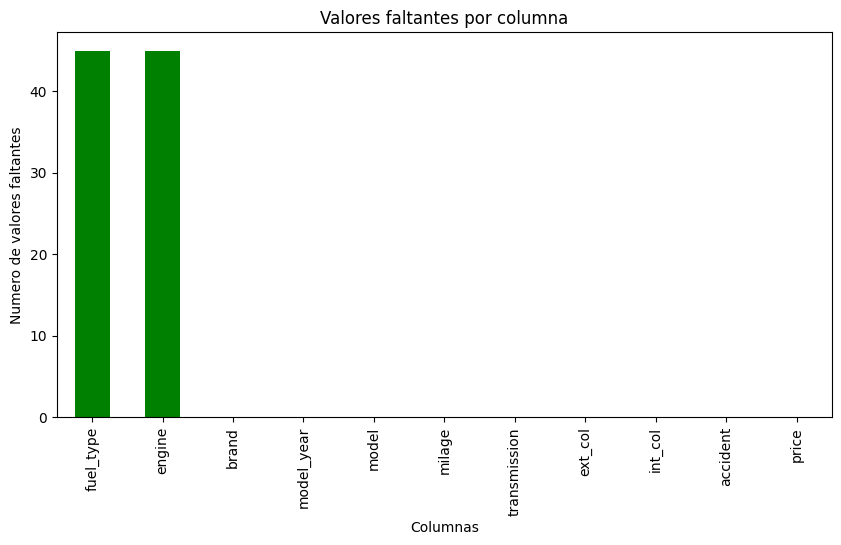

In [964]:
plt.figure(figsize=(10,5))
missing_values.plot(kind='bar',color='green')
plt.title('Valores faltantes por columna')
plt.ylabel('Numero de valores faltantes')
plt.xlabel('Columnas')
plt.show()

Vamos a mostrarlo ahora con missigno

<Axes: >

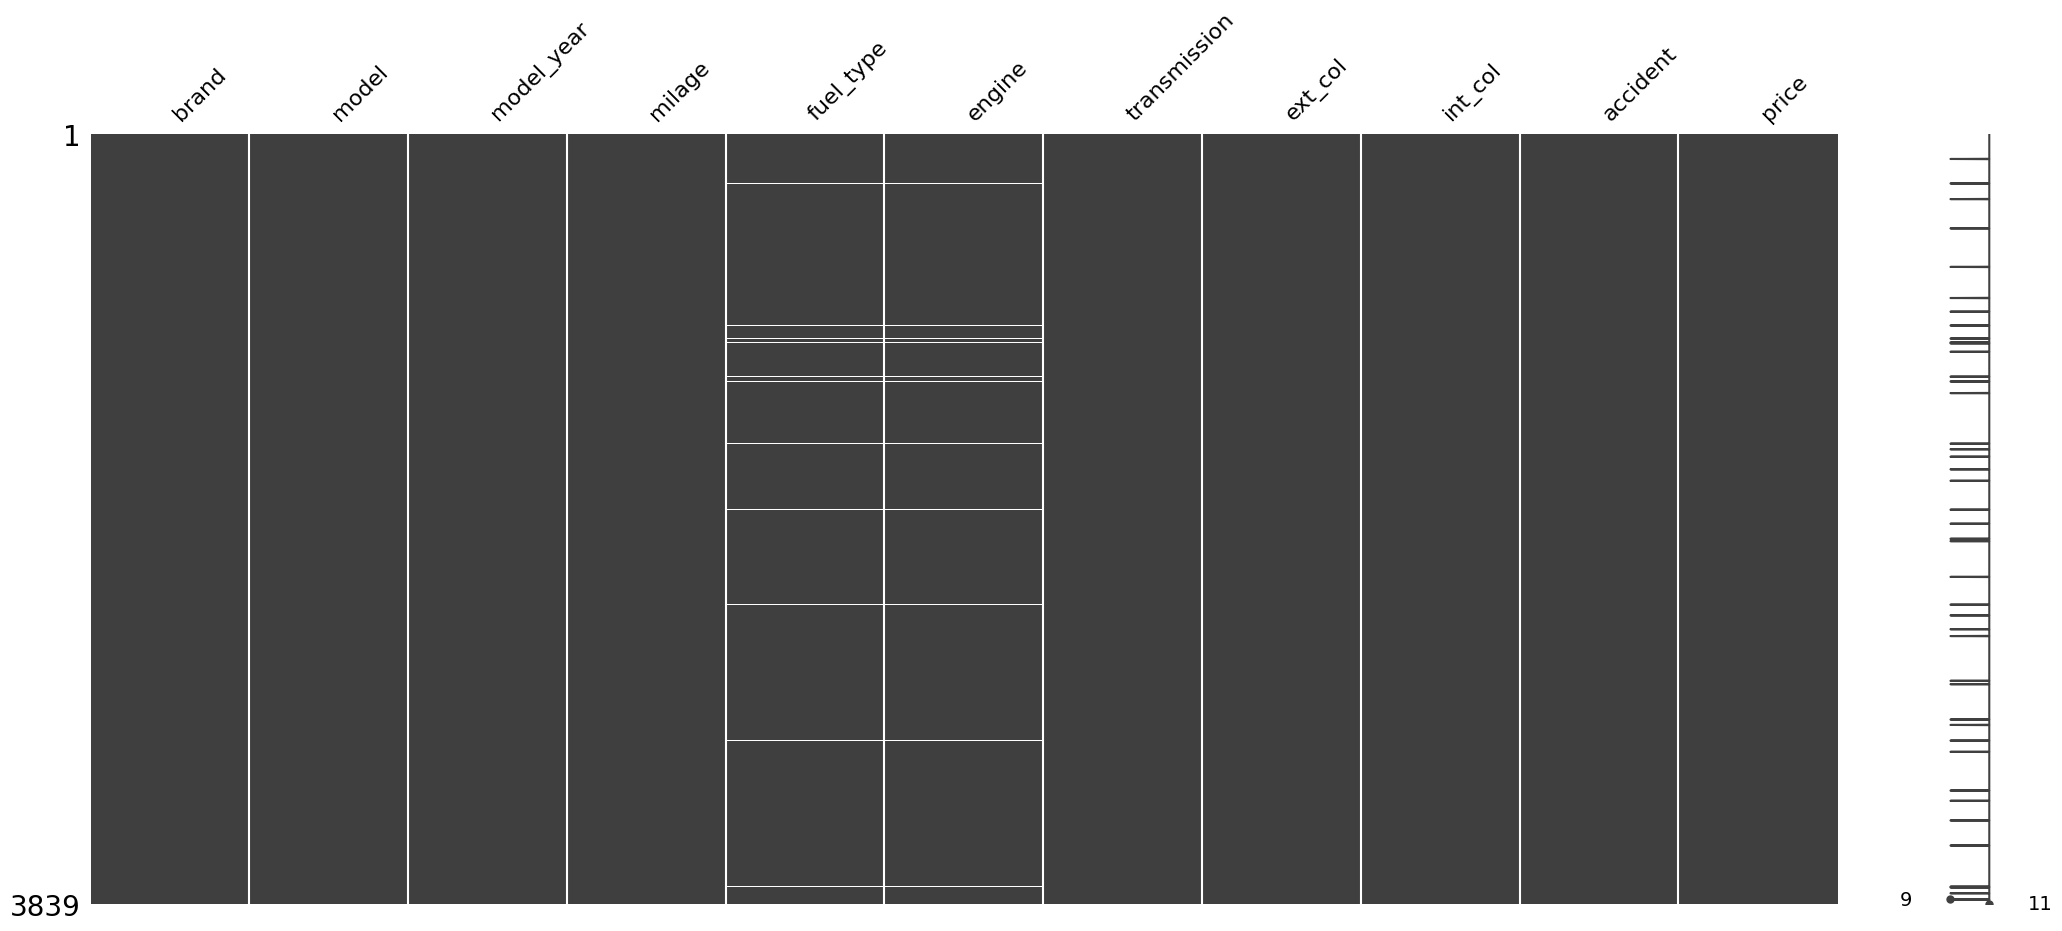

In [965]:
msno.matrix(df_clean)

Podemos observar que exactamente donde no hay valores en una columna, en la otra tampoco hay

### Detección de duplicados

Vamos a detectar posibles filas duplicadas que puedan afectar al EDA

In [966]:
duplicates = df_clean[df_clean.duplicated()]
duplicates.shape[0]

0

No existe ninguna fila duplicada

### Estudio de Outliers

En esta sección se realizará un análisis sobre posibles valores extremos que pueda distorsionar conclusiones

Outliers en columna **milage**

In [967]:
# Calculo de outliers en columna milage
# Calculamos primer y tercer quartil (Q1,Q3)
q1 = df_clean['milage'].quantile(0.25)
q3 = df_clean['milage'].quantile(0.75)

# Calculo del rango interquartil (IQR)

iqr = q3 - q1

# Límites para detectar outliers

lower_bound = q1 -1.5 *iqr
upper_bound = q3 +1.5 *iqr

# Filtrado de outliers
outliers = df_clean[( df_clean['milage'] < lower_bound) | ( df_clean['milage'] > upper_bound) ]
n_outliers = len(outliers)

print(f'lower_bound:{lower_bound}')
print(f'upper_bound:{upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'outliers encontrados: {n_outliers}')


lower_bound:-82707.5
upper_bound:203224.5
Q1: 24517.0
Q3: 96000.0
IQR: 71483.0
outliers encontrados: 65


Como las millas no pueden ser negativas, establecemos el lower_bound a cero

In [968]:
lower_bound = 0

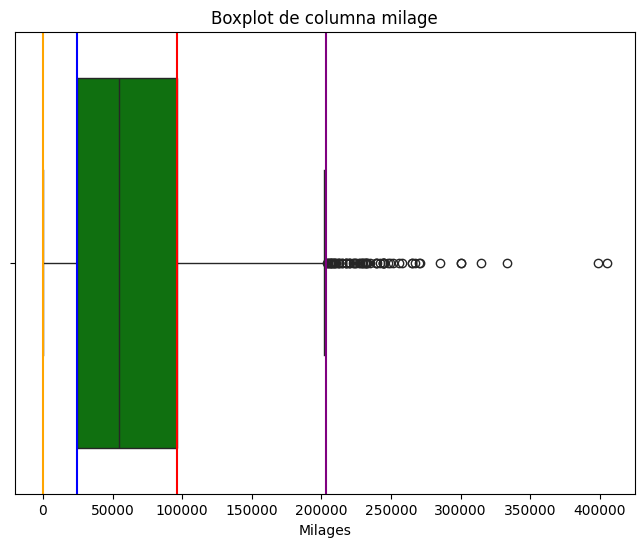

In [969]:
# Ahora mostramos un boxplot para visualizar los outliers
plt.figure(figsize=(8,6))
sns.boxplot(x=df_clean['milage'],color='green')
plt.axvline(q1,color='blue',label='Q1')
plt.axvline(q3,color='red',label='Q3')
plt.axvline(lower_bound,color='orange',label='Q1')
plt.axvline(upper_bound,color='purple',label='Q3')
plt.title('Boxplot de columna milage')
plt.xlabel('Milages')
plt.show()

Como vemos existe valores extremos pero no se consideran errores de registro por lo tanto se conservarán para análisis futuros

A continuación mostraremos un gráfico de densidad para observar donde se concentran la mayor parte de los valores

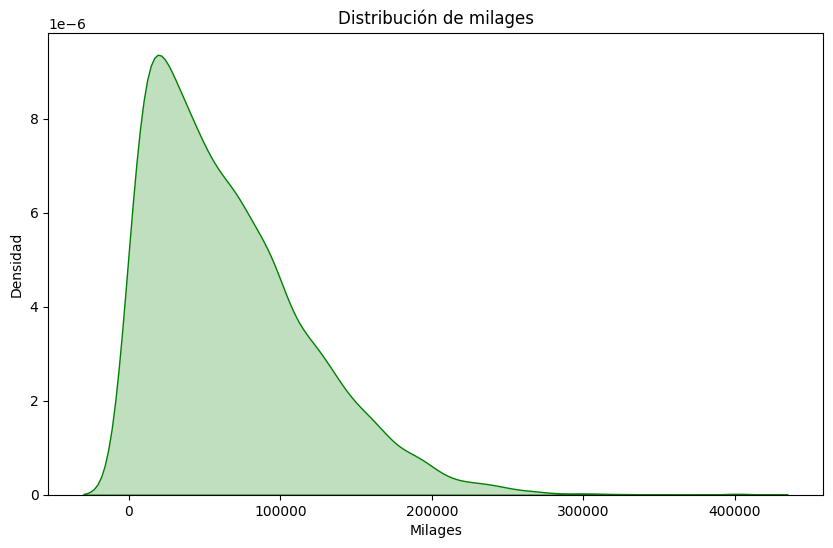

In [970]:
plt.figure(figsize=(10,6))
sns.kdeplot(df_clean['milage'],color='green',fill=True)
plt.title('Distribución de milages')
plt.xlabel('Milages')
plt.ylabel('Densidad')
plt.show()

Podemos a observar que donde se concentran la mayor parte de los valores es menor de 30000-50000 millas, a partir de ahí la densidad disminuye de manera progresiva

### Outliers en columna **price**

In [971]:
# Calculo de outliers en columna price
# Calculamos primer y tercer quartil (Q1,Q3)
q1 = df_clean['price'].quantile(0.25)
q3 = df_clean['price'].quantile(0.75)

# Calculo del rango interquartil (IQR)

iqr = q3 - q1

# Límites para detectar outliers

lower_bound = q1 -1.5 *iqr
upper_bound = q3 +1.5 *iqr

# Filtrado de outliers
outliers = df_clean[( df_clean['price'] < lower_bound) | ( df_clean['price'] > upper_bound) ]
n_outliers = len(outliers)

print(f'lower_bound:{lower_bound}')
print(f'upper_bound:{upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'outliers encontrados: {n_outliers}')


lower_bound:-30992.5
upper_bound:96947.5
Q1: 16985.0
Q3: 48970.0
IQR: 31985.0
outliers encontrados: 249


Como price no puede ser negativo, establecemos el lower_bound a cero

In [972]:
lower_bound = 0

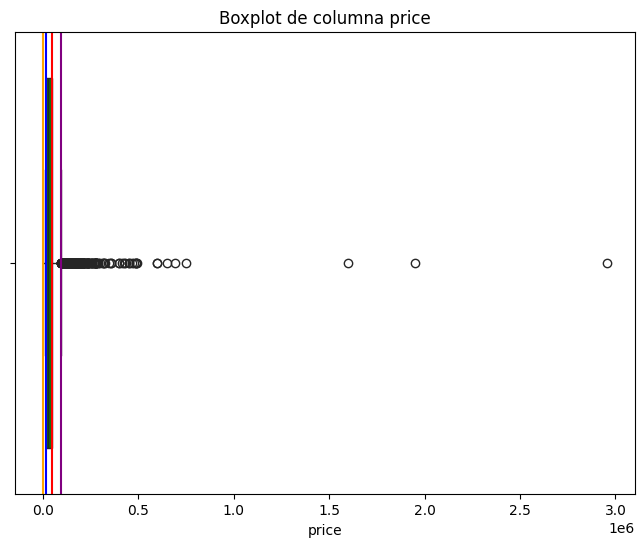

In [973]:
# Ahora mostramos un boxplot para visualizar los outliers
plt.figure(figsize=(8,6))
sns.boxplot(x=df_clean['price'],color='green')
plt.axvline(q1,color='blue',label='Q1')
plt.axvline(q3,color='red',label='Q3')
plt.axvline(lower_bound,color='orange',label='Q1')
plt.axvline(upper_bound,color='purple',label='Q3')
plt.title('Boxplot de columna price')
plt.xlabel('price')
plt.show()

Existe valores extremos pero no se considerarán como erroneos para el estudio de los mismos

Gráfico de densidad

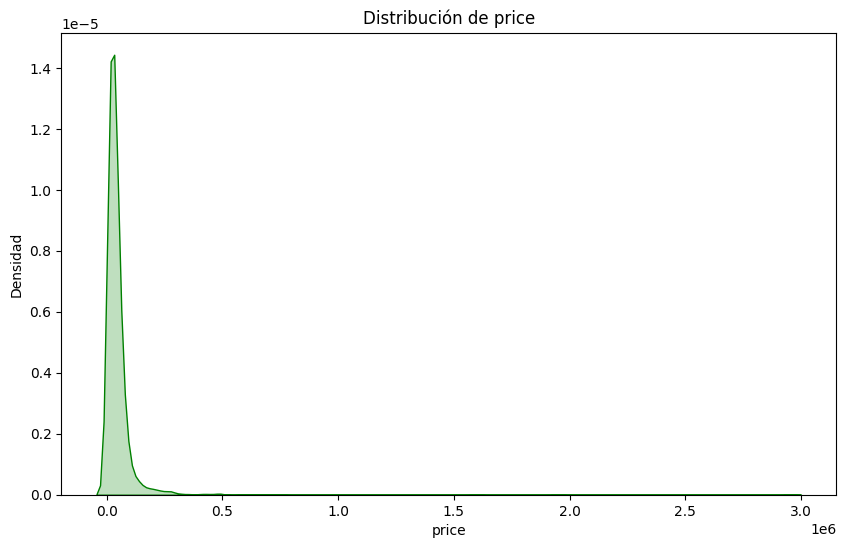

In [974]:
plt.figure(figsize=(10,6))
sns.kdeplot(df_clean['price'],color='green',fill=True)
plt.title('Distribución de price')
plt.xlabel('price')
plt.ylabel('Densidad')
plt.show()

Podemos observar los datos se acumulan en una zona y luego desciende drásticamente hasta obtener una densidad ínfima

## Análisis Exploratorio

El estudio a realizar se hará con un dataset de ventas de coches de segunda mano. Una vez realizada la limpieza y preparación del dataset, explicaremos en que consiste cada columna

* brand y model: Identifique la marca o nombre de la empresa junto con el modelo específico de cada vehículo.
* model_year: descubre el año de fabricación de los vehículos, crucial para evaluar la depreciación y los avances tecnológicos.
* milage: Obtenga el kilometraje de cada vehículo, un indicador clave del desgaste y los posibles requisitos de mantenimiento.
* fuel_type: conozca el tipo de combustible que utilizan los vehículos, ya sea gasolina, diésel, eléctrico o híbrido.
* engine: comprenda las especificaciones del motor, arrojando luz sobre el rendimiento y la eficiencia.
* transmission: Determine el tipo de transmisión, si automática, manual u otra variante.
* ext_col y int_col: explore los aspectos estéticos de los vehículos, incluidas las opciones de color exteriores e interiores.
* accident: descubra si un vehículo tiene un historial previo de accidentes o daños, crucial para una toma de decisiones informada.
* price: acceda a los precios listados para cada vehículo, lo que ayuda en la comparación de precios y la elaboración de presupuestos.

Nuestras columnas claves para el análisis serán: **Price** como variable objetivo, **milage** como relación directa con precio, **model_year** como depreciación del precio, **accident** como un impacto fuerte en el precio y **brand/model** como posible segmentación del precio

### Análisis univariado

#### Variables numéricas

Se realizará un análisis univariado de **price**,**milage** y **model_year**

#### Estadísticos descriptivos

In [975]:
df_clean['price'].describe()

count    3.839000e+03
mean     4.411657e+04
std      8.021668e+04
min      2.000000e+03
25%      1.698500e+04
50%      3.000000e+04
75%      4.897000e+04
max      2.954083e+06
Name: price, dtype: float64

In [976]:
df_clean['milage'].describe()

count      3839.000000
mean      66457.932535
std       52499.783281
min         100.000000
25%       24517.000000
50%       55000.000000
75%       96000.000000
max      405000.000000
Name: milage, dtype: float64

In [977]:
df_clean['model_year'].describe()

count    3839.000000
mean     2015.296952
std         6.124202
min      1974.000000
25%      2012.000000
50%      2017.000000
75%      2020.000000
max      2024.000000
Name: model_year, dtype: float64

### Distribución

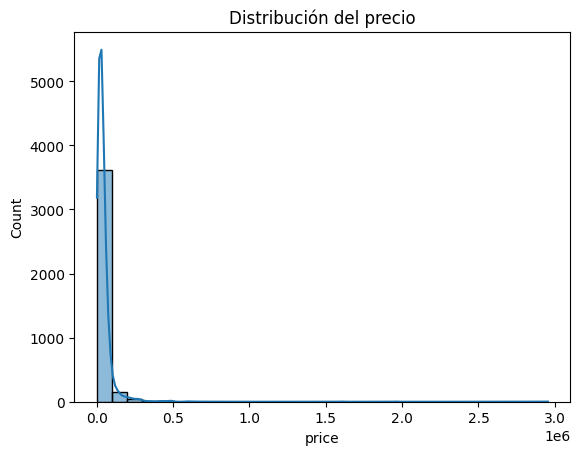

In [978]:
sns.histplot(df_clean['price'], bins=30, kde=True)
plt.title('Distribución del precio')
plt.show()

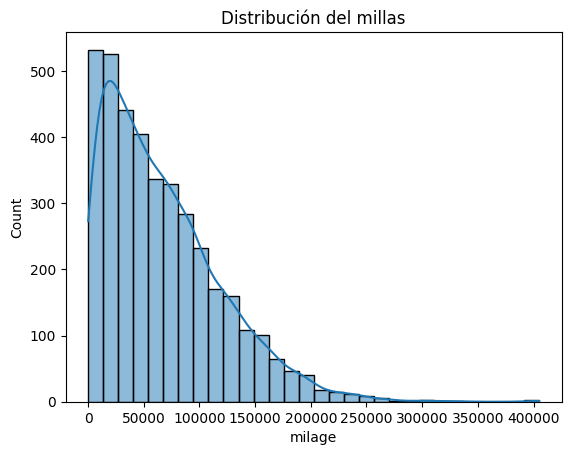

In [979]:
sns.histplot(df_clean['milage'], bins=30, kde=True)
plt.title('Distribución del millas')
plt.show()

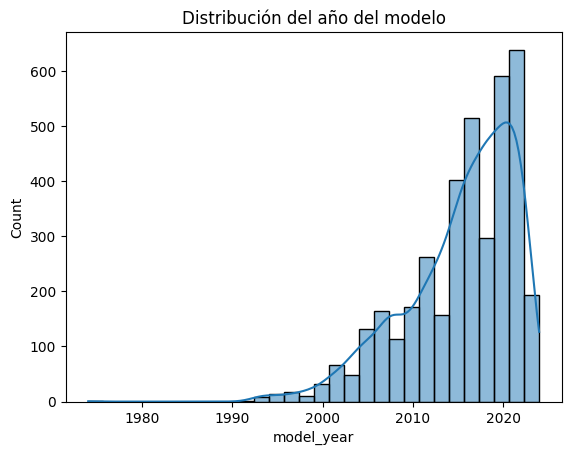

In [980]:
sns.histplot(df_clean['model_year'], bins=30, kde=True)
plt.title('Distribución del año del modelo')
plt.show()

#### Variables categóricas

Vamos a estudiar la frecuencia de algunas columnas como **brand**, **fuel_type**,**transmission** y **accident**

C:\Users\camac\AppData\Local\Temp\ipykernel_19584\2098048754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')


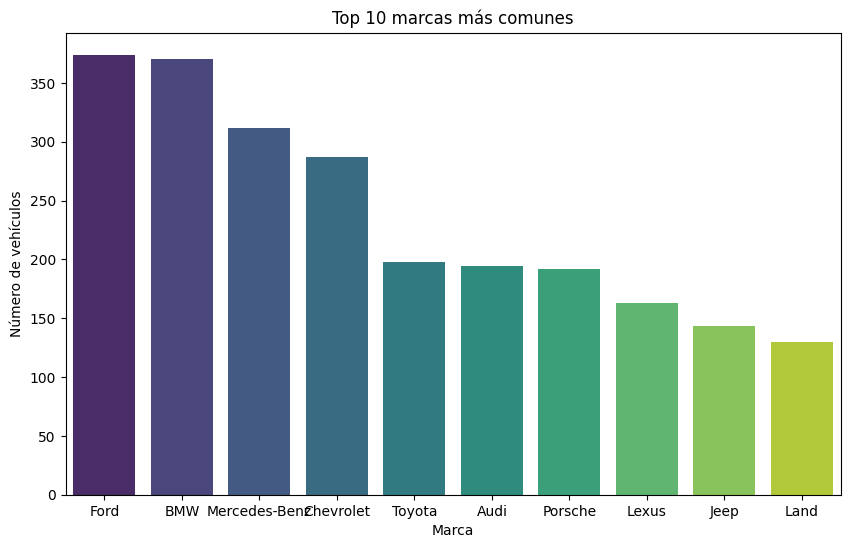

In [981]:
top_marcas = df_clean['brand'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')
plt.title('Top 10 marcas más comunes')
plt.xlabel('Marca')
plt.ylabel('Número de vehículos')
plt.show()

C:\Users\camac\AppData\Local\Temp\ipykernel_19584\2610071765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combustible.index, y=combustible.values, palette='viridis')


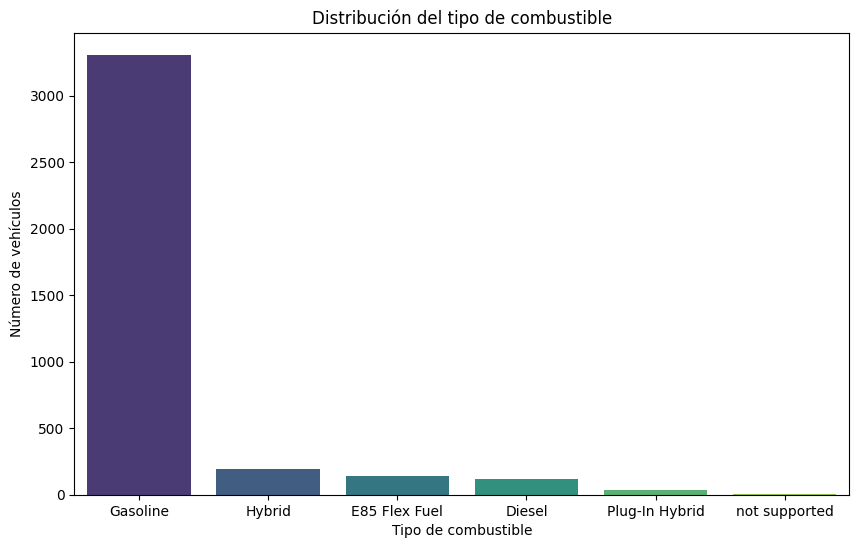

In [982]:
combustible = df_clean['fuel_type'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=combustible.index, y=combustible.values, palette='viridis')
plt.title('Distribución del tipo de combustible')
plt.xlabel('Tipo de combustible')
plt.ylabel('Número de vehículos')
plt.show()

C:\Users\camac\AppData\Local\Temp\ipykernel_19584\1406415247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transmision.index, y=transmision.values, palette='viridis')


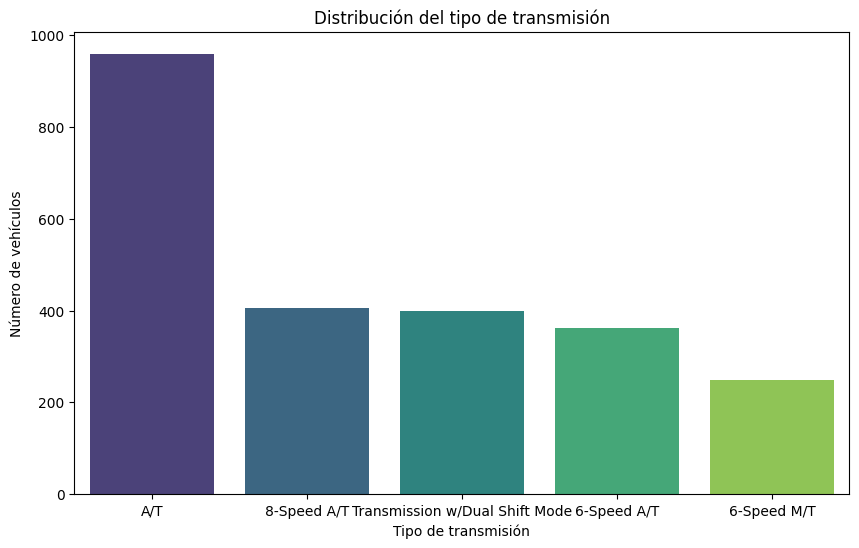

In [983]:
transmision = df_clean['transmission'].value_counts().nlargest(5)
plt.figure(figsize=(10,6))
sns.barplot(x=transmision.index, y=transmision.values, palette='viridis')
plt.title('Distribución del tipo de transmisión')
plt.xlabel('Tipo de transmisión')
plt.ylabel('Número de vehículos')
plt.show()

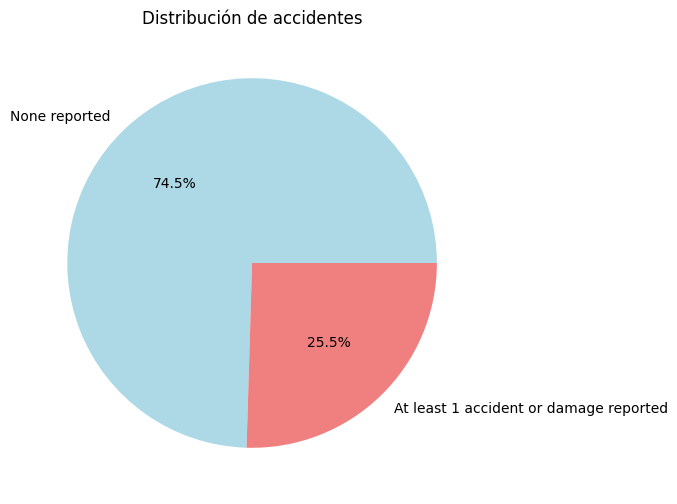

In [984]:
plt.figure(figsize=(10,6))
plt.pie(df_clean['accident'].value_counts(), labels=df_clean['accident'].value_counts().index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Distribución de accidentes')
plt.show()

### Análisis bivariado

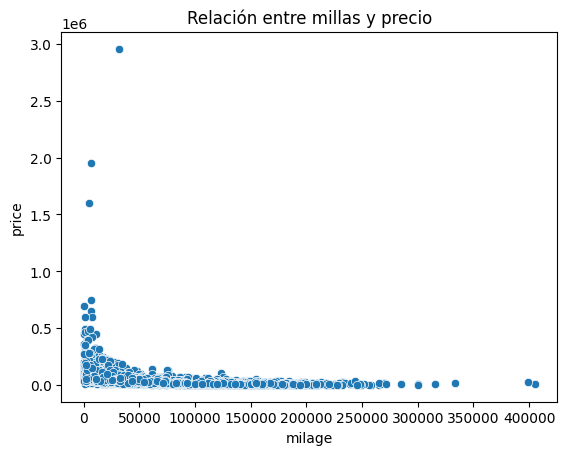

In [985]:
sns.scatterplot(x='milage', y='price', data=df_clean)
plt.title('Relación entre millas y precio')
plt.show()

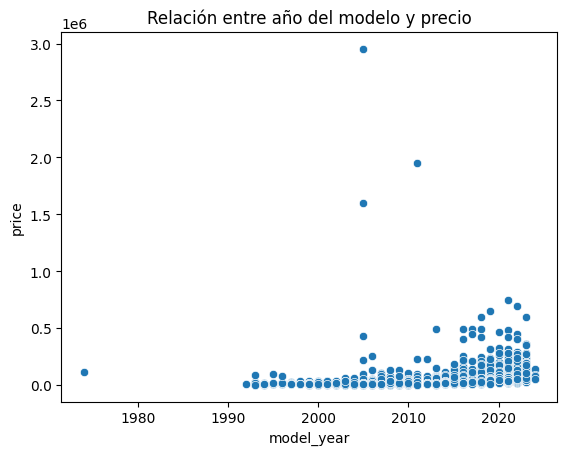

In [986]:
sns.scatterplot(x='model_year', y='price', data=df_clean)
plt.title('Relación entre año del modelo y precio')
plt.show()

<Axes: xlabel='accident', ylabel='price'>

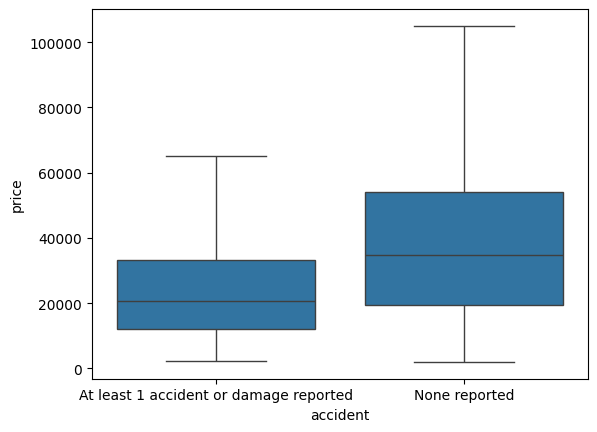

In [987]:
sns.boxplot(
    data=df_clean,
    x='accident',
    y='price',
    showfliers=False
)

### Análisis multivariado

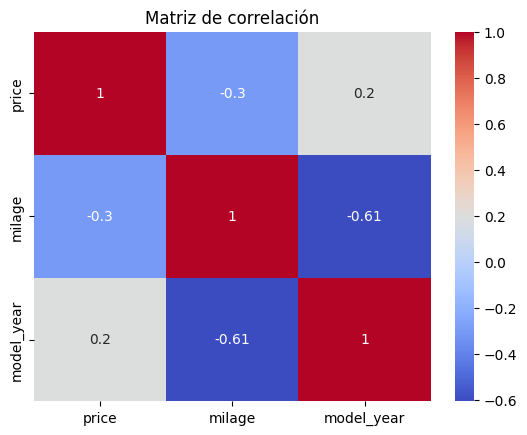

In [988]:
corr = df_clean[['price', 'milage', 'model_year']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación') 
plt.show()